In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE


In [3]:
df = pd.read_excel("C:/Cleaned_Online_Retail.xlsx")
df.dropna(subset=['Description'], inplace=True)
df.drop_duplicates(subset=['Description'], inplace=True)
df['Description'] = df['Description'].str.lower()


In [4]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),  # unigrams + bigrams
    max_df=0.8,
    min_df=2
)
tfidf_matrix = vectorizer.fit_transform(df['Description'])


In [5]:
svd = TruncatedSVD(n_components=100, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)


In [6]:
best_k = 10  # Use based on silhouette score findings
kmeans = KMeans(n_clusters=best_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(tfidf_reduced)


In [7]:
score = silhouette_score(tfidf_reduced, df['Cluster'])
print(f"✅ Silhouette Score (Enhanced KMeans): {score:.4f}")


✅ Silhouette Score (Enhanced KMeans): 0.0573


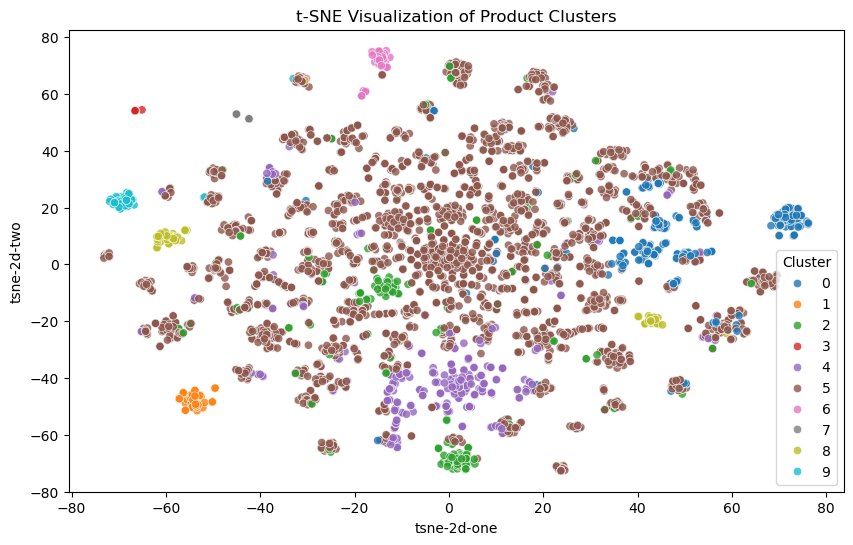

In [8]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(tfidf_reduced)

df['tsne-2d-one'] = tsne_result[:, 0]
df['tsne-2d-two'] = tsne_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='tsne-2d-one', y='tsne-2d-two',
    hue='Cluster',
    palette=sns.color_palette("tab10", best_k),
    data=df,
    legend='full', alpha=0.8
)
plt.title("t-SNE Visualization of Product Clusters")
plt.show()


In [9]:
cosine_sim_matrix = cosine_similarity(tfidf_matrix)

def recommend_similar_products_cosine(product_description, df, top_n=5):
    product_description = product_description.lower()
    if product_description not in df['Description'].values:
        print("❌ Product not found. Please check the spelling.")
        return

    idx = df[df['Description'] == product_description].index[0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_indices = sim_scores.argsort()[::-1][1:top_n+1]

    print(f"\n🔍 Top {top_n} products similar to: '{product_description}'\n")
    for i in sim_indices:
        print(f"👉 {df.iloc[i]['Description']}")


In [10]:
recommend_similar_products_cosine("white metal lantern", df)



🔍 Top 5 products similar to: 'white metal lantern'

👉 white moroccan metal lantern
👉 white with metal bag charm
👉 love seat antique white metal
👉 white lovebird lantern
👉 lantern cream gazebo 
